In [ ]:
import enum
from abc import ABCMeta, abstractmethod, abstractproperty

import numpy as np
import pandas as pd
import scipy.stats as sps
from tqdm.auto import tqdm



from matplotlib import pyplot as plt
%matplotlib inline

# Байесовские бандиты 5 баллов

#### дедлайн задания: 24 ноября, 23:59

# Работа выполнена: Уденеев Александр, Б05-203


В данной работе исследуется простая задача о многоруких бандитах с распределениями Бернулли и несколько стратегий её решения.

Бандиты имеют $K$ действий. Действие ведёт к награде $r=1$ с вероятностью $0 \le \theta_k \le 1$, неизвестной для агента, но фиксированной во времени. Цель агента состит в минимизации общей субоптимальности выполненных $T$ действий:

$$\rho = T\theta^* - \sum_{t=1}^T r_t,$$

и $\theta^* = \max_k\{\theta_k\}$.

**Пример из жизни** &mdash; клинические испытания: у нас есть $k$ видов лекарств и $T$ пациентов. После принятия лекарства пациент излечивается с вероятностью $\theta_k$. Цель состоит в поиске оптимального лекарства. Обзор по клиническим испытаниям &mdash; https://arxiv.org/pdf/1507.08025.pdf.

### Задание

Для того, чтобы получить максимальный балл, имплементируйте следующих агентов (будут указаны ниже):

1. [1 балл] $\varepsilon$-жадный алгоритм
2. [1 балл] UCB
3. [1 балл] сэмплирование по Томпсону
4. [2 балла] собственная стратегия
5. [2 балла] $\varepsilon$-жадный алгоритм для riverflow
6. [3 балла] PSRL агент для riverflow

In [2]:
SEED = 617  # Значение данной переменной не должно изменяться!


class BernoulliBandit:
    def __init__(self, n_actions=5):
        self._probs = np.random.random(n_actions)

    @property
    def action_count(self):
        return len(self._probs)

    def pull(self, action):
        if np.random.random() > self._probs[action]:
            return 0.0
        return 1.0

    def optimal_reward(self):
        """Используется для вычисления регрета"""
        return np.max(self._probs)

    def step(self):
        """Используется в нестационарной версии"""
        pass

    def reset(self):
        """Используется в нестационарной версии"""

In [3]:
class AbstractAgent(metaclass=ABCMeta):
    def init_actions(self, n_actions):
        self._successes = np.zeros(n_actions)
        self._failures = np.zeros(n_actions)
        self._total_pulls = 0

    @abstractmethod
    def get_action(self):
        """
        Получить текущее наилучшее действие
        :возвращаемый тип данных: int
        """
        pass

    def update(self, action, reward):
        """
        Учёт полученной награды в результате совершённого действия и обновление внутренних параметров агента
        :тип данных action: int
        :тип данных reward: int
        """
        self._total_pulls += 1
        if reward == 1:
            self._successes[action] += 1
        else:
            self._failures[action] += 1

    @property
    def name(self):
        return self.__class__.__name__


class RandomAgent(AbstractAgent):
    def get_action(self):
        return np.random.randint(0, len(self._successes))

### Эпсилон-жадный агент

> **for** $t = 1,2,...$ **do**

>> **for** $k = 1,...,K$ **do**

>>> $\hat\theta_k \leftarrow \alpha_k / (\alpha_k + \beta_k)$

>> **end for** 

>> $x_t \leftarrow argmax_{k}\hat\theta$ с вероятностью $1 - \varepsilon$ или равномерно случайное действие с вероятностью $\varepsilon$

>> Применить $x_t$ и получить $r_t$

>> $(\alpha_{x_t}, \beta_{x_t}) \leftarrow (\alpha_{x_t}, \beta_{x_t}) + (r_t, 1-r_t)$

> **end for**

Реализуйте описанный выше алгоритм:

In [4]:
class EpsilonGreedyAgent(AbstractAgent):
    def __init__(self, epsilon=0.01):
        self._epsilon = epsilon

    def get_action(self):
        action_argmax = np.argmax(
            self._successes / (self._successes + self._failures + 1e-9)
        )
        
        if np.random.rand() < self._epsilon:
            return np.random.choice(len(self._successes))
        return action_argmax

    @property
    def name(self):
        return self.__class__.__name__ + "(epsilon={})".format(self._epsilon)

### UCB агент
Эпсилон-жадная стратегия не имеет предпочтений на этапе случайного выбора. Возможно, лучше выбирать действия, в которых нет достаточной уверенности, но которые имеют потенциал в будущем стать оптимальными. На основе данной интуиции можно ввести меру одновременно оптмальности и неопределённости.

Одно из возможных решений для этого вополщено в UCB1 алгоритме:

> **for** $t = 1,2,...$ **do**
>> **for** $k = 1,...,K$ **do**
>>> $w_k \leftarrow \alpha_k / (\alpha_k + \beta_k) + \sqrt{2log\ t \ / \ (\alpha_k + \beta_k)}$

>> **end for** 

>> $x_t \leftarrow argmax_{k}w$

>> Применить $x_t$ и получить $r_t$

>> $(\alpha_{x_t}, \beta_{x_t}) \leftarrow (\alpha_{x_t}, \beta_{x_t}) + (r_t, 1-r_t)$

> **end for**

Другие решения и анализ оптимальности &mdash; https://homes.di.unimi.it/~cesabian/Pubblicazioni/ml-02.pdf.

In [25]:
class UCBAgent(AbstractAgent):
    def get_action(self):
        # чтобы во втором слагаемом не было деления не 0, сначала выполним каждое действие
        untried_actions = np.where((self._successes + self._failures) == 0)[0]
        if len(untried_actions) > 0:
            return np.random.choice(untried_actions)
        
        w = self._successes / (self._successes + self._failures + 1e-9) + np.sqrt(
            2 * np.log(self._total_pulls) / (self._successes + self._failures)
        )

        x = np.argmax(w)
        return x

### Сэмплирование по Томпсону

UCB1 не рассматривает распределение наград. Если оно известно, то можно улучшить UCB1 алгоритм добавлением сэмплирования по Томпсону.

Предполагается, что $\theta_k$ независимые и одинаково распределены. В качестве априорного распределения будем использовать бета-распределение с параметрами $\alpha=(\alpha_1, \dots, \alpha_k)$ и $\beta=(\beta_1, \dots, \beta_k)$. Следовательно, для каждого параметра $\theta_k$ функция плотности априорного распределения выглядит как
$$
p(\theta_k) =
\frac{\Gamma(\alpha_k + \beta_k)}{\Gamma(\alpha_k)\Gamma(\beta_k)}
\theta_k^{\alpha_k - 1}(1 - \theta_k)^{\beta_k - 1}
$$
После получения нового наблюдения распределение обновляется согласно правилу Байеса.

C бета-распределением удобно работать из-за сопряжения &mdash; апостериорное распределение будет так же бета-распределением, поэтому параметры можно легко обновлять:

> **for** $t = 1,2,...$ **do**
>> **for** $k = 1,...,K$ **do**
>>> Сэмплировать $\hat\theta_k \sim beta(\alpha_k, \beta_k)$

>> **end for** 

>> $x_t \leftarrow argmax_{k}\hat\theta$

>> Применить $x_t$ и получить $r_t$

>> $(\alpha_{x_t}, \beta_{x_t}) \leftarrow (\alpha_{x_t}, \beta_{x_t}) + (r_t, 1-r_t)$

> **end for**
 
Теория и практика сэмплирования по Томпсону: https://web.stanford.edu/~bvr/pubs/TS_Tutorial.pdf.

In [26]:
class ThompsonSamplingAgent(AbstractAgent):
    def get_action(self):
        theta = sps.beta((self._successes + 1), (self._failures + 1)).rvs()
        x = np.argmax(theta)
        return x

In [27]:
def plot_regret(env, agents, n_steps=5000, n_trials=50):
    scores = {agent.name: [0.0 for step in range(n_steps)] for agent in agents}

    for trial in tqdm(range(n_trials), desc="Trials"):
        env.reset()

        for a in agents:
            a.init_actions(env.action_count)

        for i in range(n_steps):
            optimal_reward = env.optimal_reward()

            for agent in agents:
                action = agent.get_action()
                reward = env.pull(action)
                agent.update(action, reward)
                scores[agent.name][i] += optimal_reward - reward

            env.step()  # изменяет состояние бандита в случае нестацинарности среды

    plt.figure(figsize=(17, 8))
    for agent in agents:
        plt.plot(np.cumsum(scores[agent.name]) / n_trials)

    plt.legend([agent.name for agent in agents])

    plt.ylabel("регрет")
    plt.xlabel("шаги")

    plt.show()

Trials:   0%|          | 0/10 [00:00<?, ?it/s]

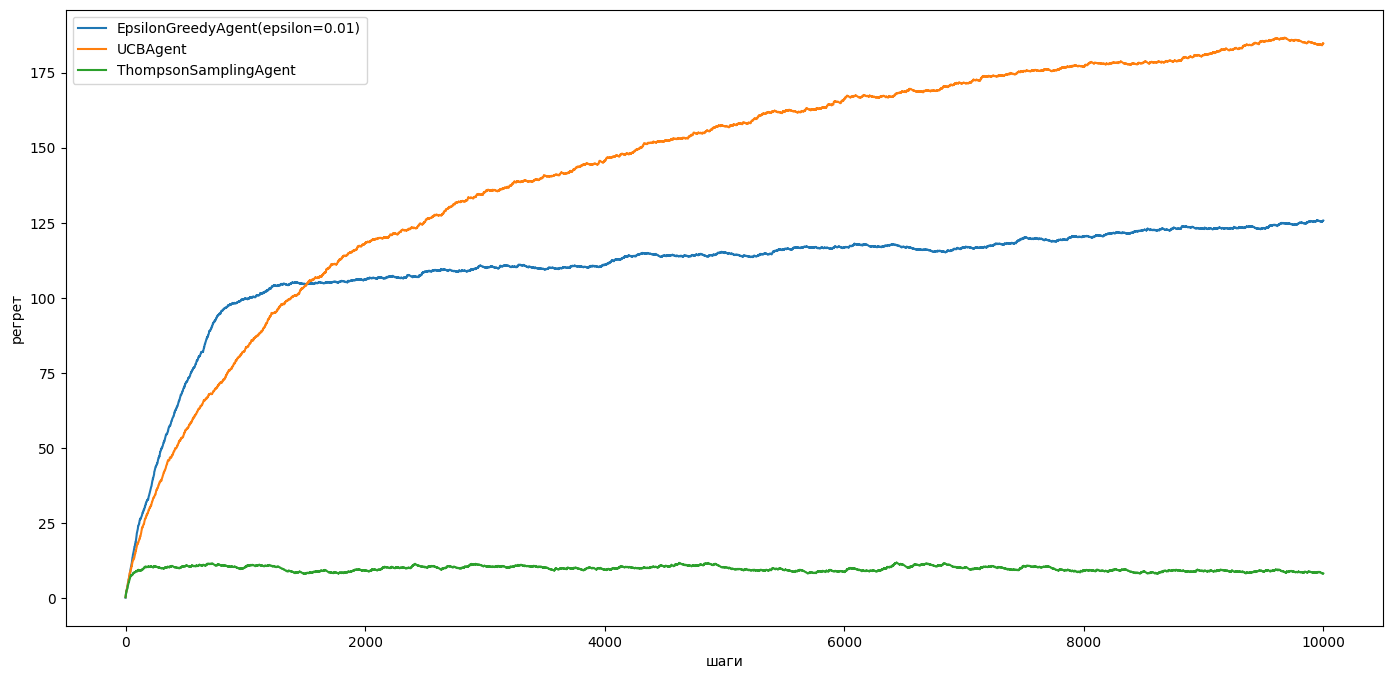

CPU times: user 54.9 s, sys: 1.59 s, total: 56.5 s
Wall time: 54.1 s


In [28]:
%%time
np.random.seed(SEED)


agents = [
     EpsilonGreedyAgent(),
     UCBAgent(),
     ThompsonSamplingAgent()
]

plot_regret(BernoulliBandit(), agents, n_steps=10000, n_trials=10)

Как видим, алгоритм Томпсона намного лучше других алгоритмов. Также можем наблюдать, что в данной ситуации дополнительные исследовании в UCB лишь навредило, то есть модель слишком сильно занимается exploration, вместо explotation, из-за чего и проигрывает примитивному алгоритму $\epsilon$-greedy

# Нестационарные бандиты

Но что в случае изменяющихся со временем вероятностей? Например:

In [30]:
class DriftingBandit(BernoulliBandit):
    def __init__(self, n_actions=5, gamma=0.01):
        """
        Идея взята из https://github.com/iosband/ts_tutorial
        """
        super().__init__(n_actions)

        self._gamma = gamma

        self._successes = None
        self._failures = None
        self._steps = 0

        self.reset()

    def reset(self):
        self._successes = np.zeros(self.action_count) + 1.0
        self._failures = np.zeros(self.action_count) + 1.0
        self._steps = 0

    def step(self):
        action = np.random.randint(self.action_count)
        reward = self.pull(action)
        self._step(action, reward)

    def _step(self, action, reward):
        self._successes = self._successes * (1 - self._gamma) + self._gamma
        self._failures = self._failures * (1 - self._gamma) + self._gamma
        self._steps += 1

        self._successes[action] += reward
        self._failures[action] += 1.0 - reward

        self._probs = np.random.beta(self._successes, self._failures)

Обратите внимание на вероятности наград, изменяющиеся со временем:

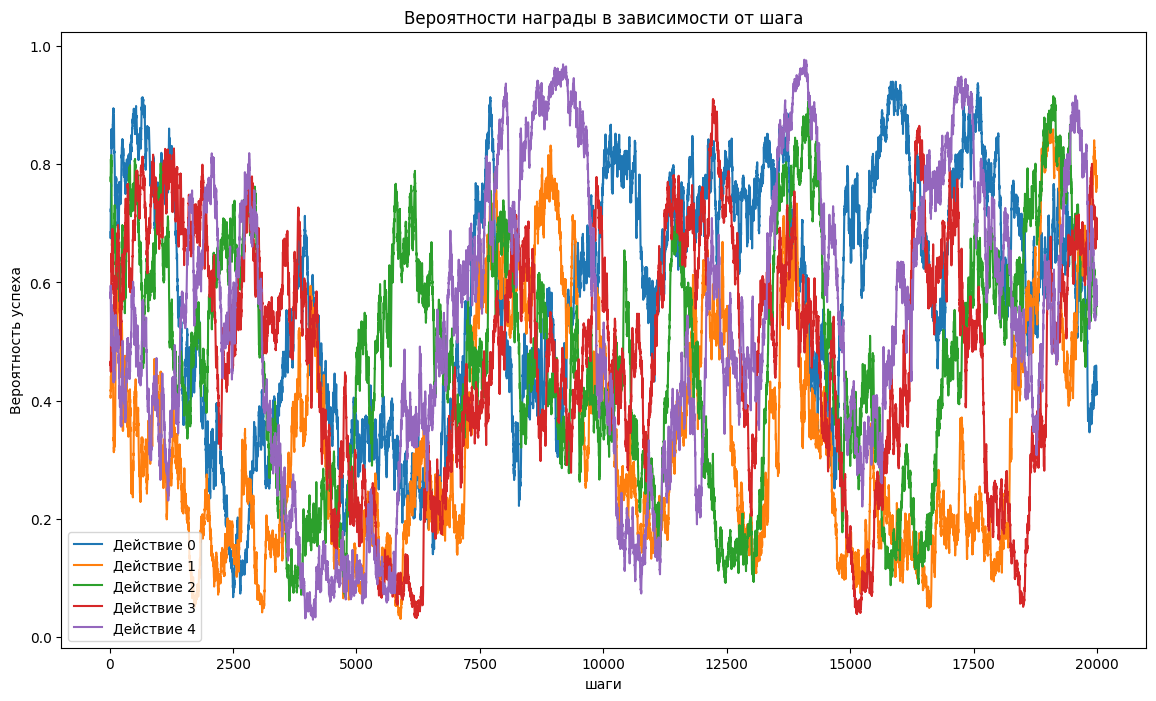

CPU times: user 1.05 s, sys: 35.5 ms, total: 1.08 s
Wall time: 1.04 s


In [31]:
%%time
np.random.seed(SEED)


drifting_env = DriftingBandit(n_actions=5)

drifting_probs = []
for i in range(20000):
    drifting_env.step()
    drifting_probs.append(drifting_env._probs)

plt.figure(figsize=(14, 8))
plt.plot(pd.DataFrame(drifting_probs).rolling(window=20).mean())

plt.xlabel("шаги")
plt.ylabel("Вероятность успеха")
plt.title("Вероятности награды в зависимости от шага")
plt.legend(["Действие {}".format(i) for i in range(drifting_env.action_count)])
plt.show()

**Задача** &mdash; создать агента, который будет работать лучше каждой рассмотренной выше стационарной стратегии.

Попробуем реализовать [DiscountedUCB](https://arxiv.org/pdf/0805.3415) 

> **for** *t = 1, 2, …**do**  
>> **for** *k = 1,…,K**do**  
>>>  $\hat{\mu}_k \leftarrow s_k / (s_k + f_k)$  
>>>  
>>>  $w_k \leftarrow \hat{\mu}_k + \sqrt{\dfrac{2\,\log(\sum_j (s_j+f_j) + 1)}{s_k + f_k}}$  
>> **end for**
>>
>>  $x_t \leftarrow \arg\max_k w_k$  
>>
>>  Применить $x_t$ и получить $r_t \in \{0,1\}$  
>>
>>  **для всех** *k = 1,…,K*   **выполнить** (экспоненциальное забывание)  
>>>  $s_k \leftarrow γ\,s_k$  
>>>  $f_k \leftarrow γ\,f_k$
>>
>>  Обновить только выбранное действие $x_t$  
>>>  $s_{x_t} \leftarrow s_{x_t} + r_t$  
>>>  $f_{x_t} \leftarrow f_{x_t} + (1 − r_t)$  
>
> **end for**

In [93]:
class YourAgent(AbstractAgent):
    def __init__(self, gamma=0.0005):
        self._gamma = gamma

    def get_action(self):
        untried_actions = np.where((self._successes + self._failures) == 0)[0]
        if len(untried_actions) > 0:
            return np.random.choice(untried_actions)

        mu = self._successes / (self._successes + self._failures)
        w = mu + np.sqrt(
            2
            * np.log(1 + np.sum(self._successes + self._failures))
            / (self._successes + self._failures)
        )
        return np.argmax(w)

    def update(self, action, reward):
        """
        Учёт полученной награды в результате совершённого действия и обновление внутренних параметров агента
        :тип данных action: int
        :тип данных reward: int
        """
        self._successes *= 1 - self._gamma
        self._failures *= 1 - self._gamma

        if reward == 1:
            self._successes[action] += 1
        else:
            self._failures[action] += 1

Trials:   0%|          | 0/20 [00:00<?, ?it/s]

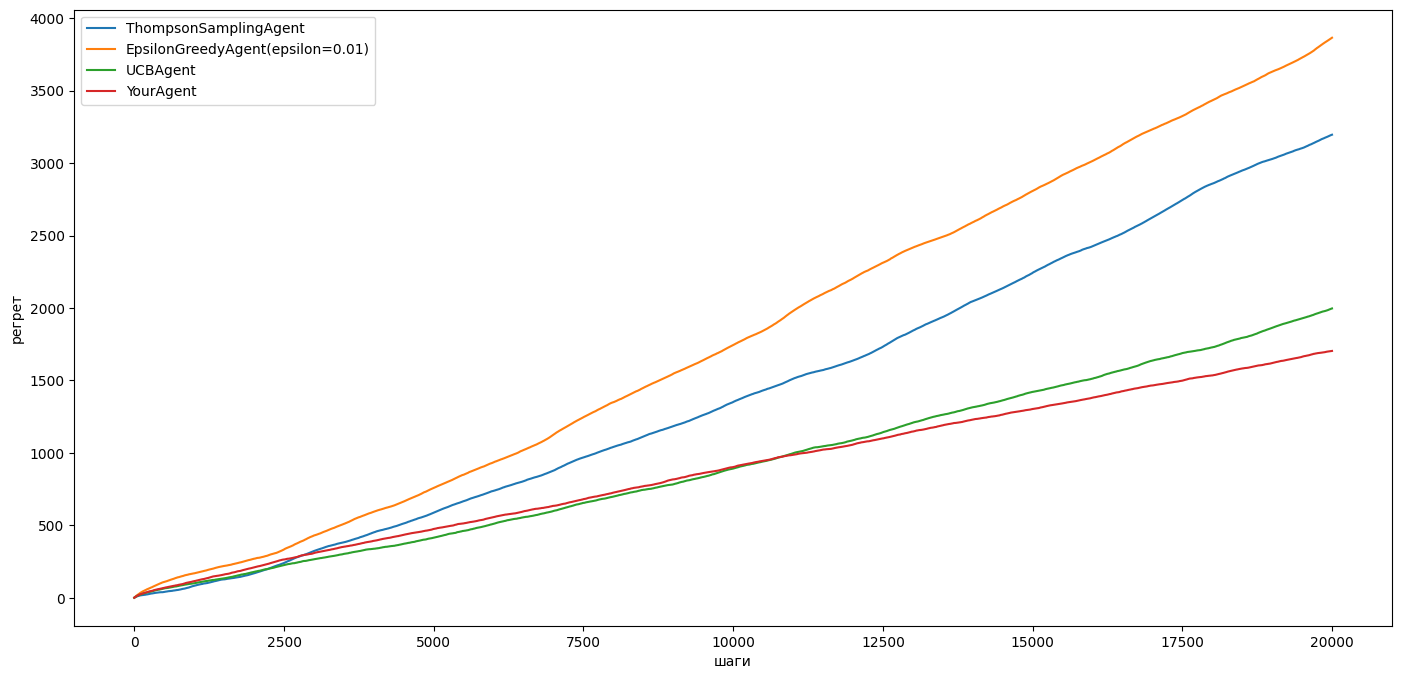

CPU times: user 3min 58s, sys: 1.67 s, total: 4min
Wall time: 3min 58s


In [ ]:
%%time
np.random.seed(SEED)


drifting_agents = [
    ThompsonSamplingAgent(),
    EpsilonGreedyAgent(),
    UCBAgent(),
    YourAgent()
]

plot_regret(DriftingBandit(), drifting_agents, n_steps=20000, n_trials=20)

Как видим, начиная где-то с 10000-го шага, наша стратегия учета успеха и неудачи начинает приносить плоды, и DiscountedUCB начинает обходить обычный UCB

## Исследование среды в MDP

Следующая задача, "river flow", демонстрирует важность исследования среды на примере Марковского процесса принятия решений.

<img src="river_swim.png">

Рисунок взят из https://arxiv.org/abs/1306.0940

Награды и вероятности переходов агенту не известны.

Оптимальная стратегия состоит в том, чтобы идти направо против потока, тогда как легче будет идти налево и получать небольшую награду каждый раз.

In [116]:
class RiverSwimEnv:
    LEFT_REWARD = 5.0 / 1000
    RIGHT_REWARD = 1.0

    def __init__(self, intermediate_states_count=4, max_steps=16):
        self._max_steps = max_steps
        self._current_state = None
        self._steps = None
        self._interm_states = intermediate_states_count
        self.reset()

    def reset(self):
        self._steps = 0
        self._current_state = 1
        return self._current_state, 0.0, False

    @property
    def n_actions(self):
        return 2

    @property
    def n_states(self):
        return 2 + self._interm_states

    def _get_transition_probs(self, action):
        if action == 0:
            if self._current_state == 0:
                return [0, 1.0, 0]
            else:
                return [1.0, 0, 0]

        elif action == 1:
            if self._current_state == 0:
                return [0, 0.4, 0.6]
            if self._current_state == self.n_states - 1:
                return [0.4, 0.6, 0]
            else:
                return [0.05, 0.6, 0.35]
        else:
            raise RuntumeError(
                "Неизвестное действие {}. Максимальное количество действий {}".format(
                    action, self.n_actions
                )
            )

    def step(self, action):
        """
        :параметр action:
        :тип данных action: int
        :возвращает: observation, reward, is_done
        :тип возвращаемых данных: (int, float, bool)
        """
        reward = 0.0

        if self._steps >= self._max_steps:
            return self._current_state, reward, True

        transition = np.random.choice(range(3), p=self._get_transition_probs(action))
        if transition == 0:
            self._current_state -= 1
        elif transition == 1:
            pass
        else:
            self._current_state += 1

        if self._current_state == 0:
            reward = self.LEFT_REWARD
        elif self._current_state == self.n_states - 1:
            reward = self.RIGHT_REWARD

        self._steps += 1
        return self._current_state, reward, False

Ниже предлагается реализовать Q-обучение агента с $\varepsilon$-жадной стратегией и посмотреть на производительность данного решения.

In [ ]:
class QLearningAgent:
    def __init__(self, n_states, n_actions, lr=0.2, gamma=0.95, epsilon=0.1):
        self._gamma = gamma
        self._epsilon = epsilon
        self._q_matrix = np.zeros((n_states, n_actions))
        self._lr = lr

    def get_action(self, state):
        if np.random.random() < self._epsilon:
            return np.random.randint(0, self._q_matrix.shape[1])
        else:
            return np.argmax(self._q_matrix[state])

    def get_q_matrix(self):
        """Используется для визуализации политики"""

        return self._q_matrix

    def start_episode(self):
        """Используется в PSRL агенте"""
        pass

    def update(self, state, action, reward, next_state):
        self._q_matrix[state, action] += self._lr * (
            reward
            + self._gamma * np.max(self._q_matrix[next_state])
            - self._q_matrix[state, action]
        )

In [118]:
def train_mdp_agent(agent, env, n_episodes):
    episode_rewards = []

    for ep in range(n_episodes):
        state, ep_reward, is_done = env.reset()
        agent.start_episode()
        while not is_done:
            action = agent.get_action(state)

            next_state, reward, is_done = env.step(action)
            agent.update(state, action, reward, next_state)

            state = next_state
            ep_reward += reward

        episode_rewards.append(ep_reward)
    return episode_rewards

In [119]:
import pandas as pd

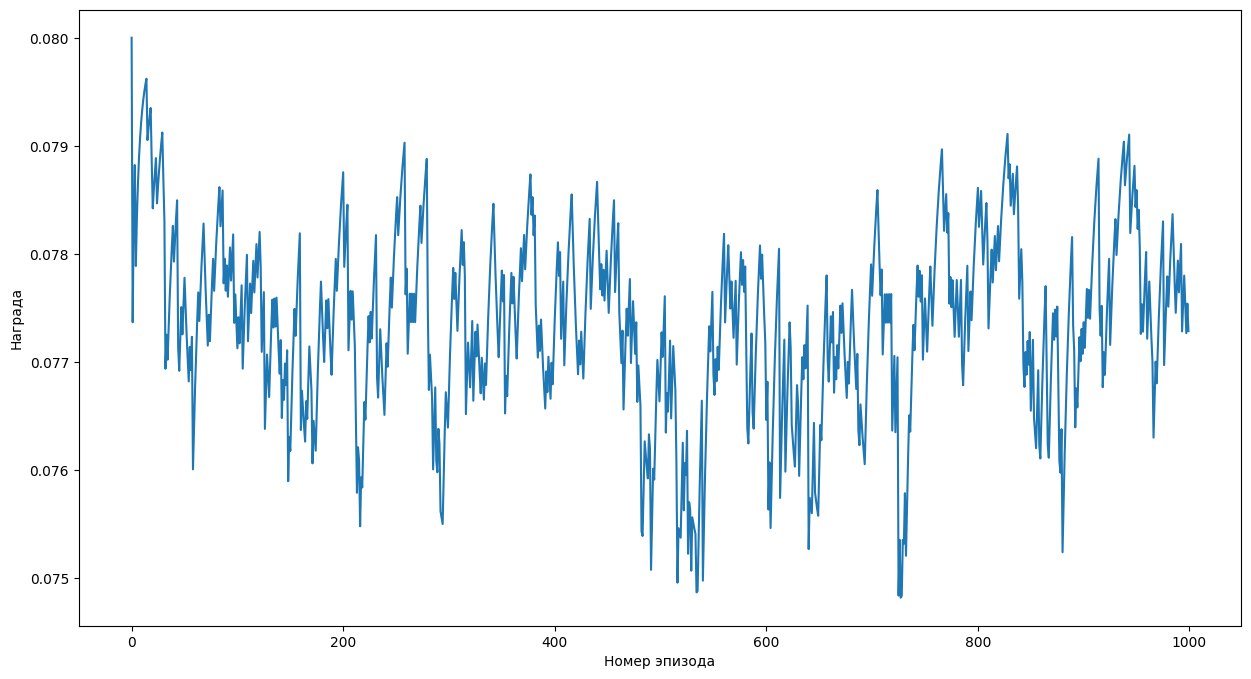

CPU times: user 543 ms, sys: 40.7 ms, total: 583 ms
Wall time: 538 ms


In [120]:
%%time
np.random.seed(SEED)


env = RiverSwimEnv()
agent = QLearningAgent(env.n_states, env.n_actions)
rews = train_mdp_agent(agent, env, 1000)
plt.figure(figsize=(15, 8))

plt.plot(pd.DataFrame.ewm(pd.DataFrame(np.array(rews)),alpha=.1).mean())
plt.xlabel("Номер эпизода")
plt.ylabel("Награда")
plt.show()

Ниже реализована визуализация решений агента:

In [121]:
def plot_policy(agent):
    fig = plt.figure(figsize=(15, 8))
    ax = fig.add_subplot(111)
    cax = ax.matshow(agent.get_q_matrix().T, cmap="viridis")
    plt.colorbar(cax, ax=ax, label="Q-value")
    ax.set_xlabel("Состояние")
    ax.set_ylabel("Действие")
    ax.set_title("Значения Q-функции")
    ax.set_yticks(range(agent.get_q_matrix().shape[1]))
    ax.set_yticklabels(["лево", "право"])
    plt.show()

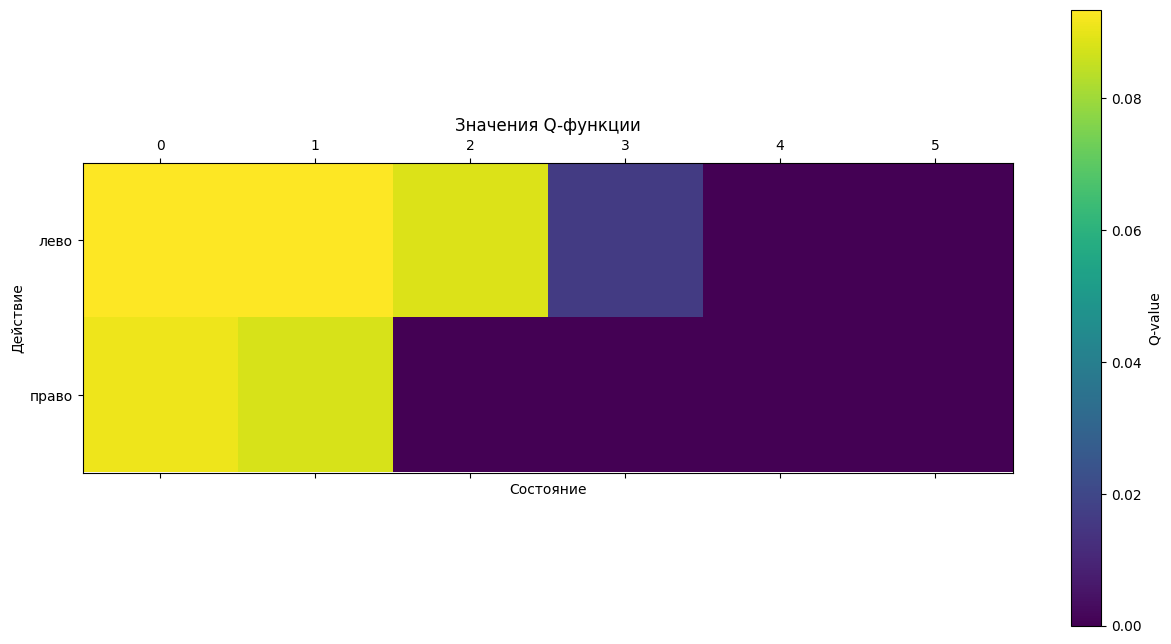

In [122]:
plot_policy(agent)

Видно, что агент использует неоптимальную стратегию и продолжает идти налево, не зная про вариант получше.

## Posterior sampling RL

Настало время реализовать сэмплирование по Томпсону для MDP!

Алгоритм:

>**for** эпизода $k = 1,2,...$ **do**
>> сэмплировать $M_k \sim f(\bullet\ |\ H_k)$

>> Вычислить политику $\mu_k$ для $M_k$

>> **for** шагов $t = 1, 2,...$ **do**

>>> выбрать действие  $a_t$ из $\mu_k$ 

>>> получить $r_t$ и $s_{t+1}$
>>> обновить $H_k$

>> **end for**

>**end for**

Марковский процесс принятия решений $M_k$ представлен двумя матрицами: вероятности переходов и награды. Матрица переходов сэмплируется из распределения Дирихле, в то время как матрица наград сэмплируется из гамма-нормального распределения.

Распределения обновляются согласно правилу Байеса (см. https://en.wikipedia.org/wiki/Conjugate_prior для непрерывных распределений).

Дополнительные материалы &mdash; https://arxiv.org/abs/1306.0940.

In [128]:
def sample_normal_gamma(mu, lmbd, alpha, beta):
    """https://en.wikipedia.org/wiki/Normal-gamma_distribution"""
    tau = np.random.gamma(alpha, beta)
    mu = np.random.normal(mu, 1.0 / np.sqrt(lmbd * tau))
    return mu, tau


class PsrlAgent:
    def __init__(self, n_states, n_actions, horizon=10, gamma=0.99):
        self._n_states = n_states
        self._n_actions = n_actions
        self._horizon = horizon
        self._gamma = gamma

        # параметры для сэмплирования матрицы переходов --- распределение Дирихле
        self._transition_counts = np.zeros((n_states, n_states, n_actions)) + 1.0

        # параметры для сэмплирования наград --- гамма-нормальное распределение
        self._mu_matrix = np.zeros((n_states, n_actions)) + 1.0
        self._state_action_counts = np.zeros((n_states, n_actions)) + 1.0  # lambda

        self._alpha_matrix = np.zeros((n_states, n_actions)) + 1.0
        self._beta_matrix = np.zeros((n_states, n_actions)) + 1.0

    def _sample_mdp(self):
        transitions = np.zeros_like(self._transition_counts)
        rewards = np.zeros_like(self._mu_matrix)
        for s in range(self._n_states):
            for a in range(self._n_actions):
                transitions[s, :, a] = np.random.dirichlet(
                    self._transition_counts[s, :, a]
                )
                rewards[s, a], _ = sample_normal_gamma(
                    self._mu_matrix[s, a],
                    self._state_action_counts[s, a],
                    self._alpha_matrix[s, a],
                    self._beta_matrix[s, a],
                )
        return transitions, rewards

    def _value_iteration(self, transitions, rewards):
        state_values = np.zeros(self._n_states)
        for _ in range(self._horizon):
            new_values = np.zeros_like(state_values)
            for s in range(self._n_states):
                q = np.zeros(self._n_actions)
                for a in range(self._n_actions):
                    q[a] = rewards[s, a] + self._gamma * np.dot(
                        transitions[s, :, a], state_values
                    )
                new_values[s] = np.max(q)
            state_values = new_values
        return state_values

    def start_episode(self):
        # сэмпл нового Марковского процесса принятия решений
        self._sampled_transitions = np.apply_along_axis(
            np.random.dirichlet, 1, self._transition_counts
        )

        sampled_reward_mus, sampled_reward_stds = sample_normal_gamma(
            self._mu_matrix,
            self._state_action_counts,
            self._alpha_matrix,
            self._beta_matrix,
        )

        self._sampled_rewards = sampled_reward_mus
        self._current_value_function = self._value_iteration(
            self._sampled_transitions, self._sampled_rewards
        )

    def get_action(self, state):
        return np.argmax(
            self._sampled_rewards[state]
            + self._current_value_function.dot(self._sampled_transitions[state])
        )

    def update(self, state, action, reward, next_state):
        self._transition_counts[state, next_state, action] += 1

        # 2. Обновление параметров нормально-гамма распределения для наград
        n = self._state_action_counts[state, action]

        mu_old = self._mu_matrix[state, action]
        self._state_action_counts[state, action] += 1
        self._mu_matrix[state, action] = (n * mu_old + reward) / (n + 1)
        self._alpha_matrix[state, action] += 0.5

        # Wikipedia: Normal-gamma distribution
        squared_diff = (reward - mu_old) ** 2
        self._beta_matrix[state, action] += 0.5 * n * squared_diff / (n + 1)

    def get_q_matrix(self):
        return self._sampled_rewards + self._current_value_function.dot(
            self._sampled_transitions
        )

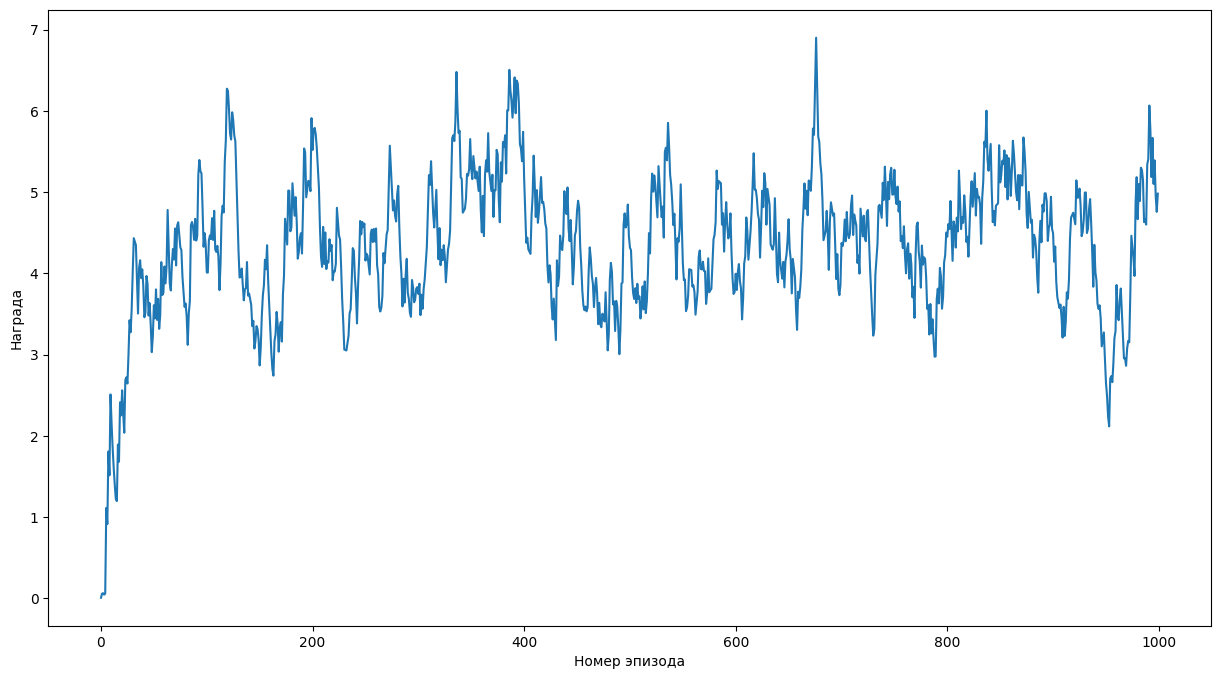

CPU times: user 1.75 s, sys: 4.95 ms, total: 1.75 s
Wall time: 1.75 s


In [126]:
%%time
np.random.seed(SEED)


horizon = 20
env = RiverSwimEnv(max_steps=horizon)
agent = PsrlAgent(env.n_states, env.n_actions, horizon=horizon)
rews = train_mdp_agent(agent, env, 1000)

plt.figure(figsize=(15, 8))
plt.plot(pd.DataFrame.ewm(pd.DataFrame(np.array(rews)), alpha=0.1).mean())

plt.xlabel("Номер эпизода")
plt.ylabel("Награда")
plt.show()

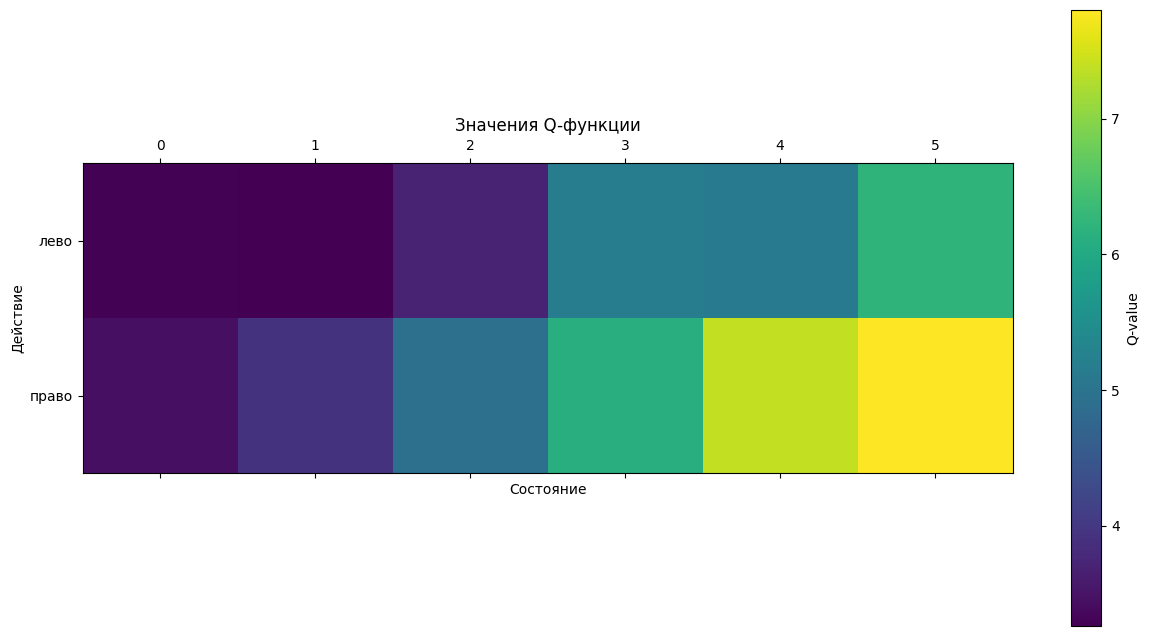

In [127]:
plot_policy(agent)

Победа, теперь агент достаточно смел в исследованиях, и смог выяснить, что правая позиция намного более выгоднее левой.